# 05 - Hierarchical Concept Analysis & Macro-Clusters

In this notebook, we group the **BioMedCLIP medical concepts** from Step 02 into **semantic macro-clusters** and analyze the concept-level verdicts saved in Step 04.

We use the phrase-level dictionary from Step 02 and the evaluation CSV files from Step 04.


## 1. Setup and Imports

On Colab, clone the GitHub repository into `/content/xai-project5` and mount Google Drive to access the saved evaluation results. Locally, use the existing repository. Install the project requirements and import the clustering and plotting utilities.

Read evaluation CSVs from `04_evaluation` and write all notebook outputs to `05_hierarchical_clustering` (on Google Drive in Colab). Each requested cluster count has a separate `k_<value>` subdirectory.


In [2]:
import sys
import os
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_url = "https://github.com/emmanuelmessina00/xai-project5.git"
    base_dir = "/content/xai-project5"

    if not os.path.exists(base_dir):
        subprocess.run(["git", "clone", "--depth", "1", repo_url, base_dir], check=True)
    else:
        print(f"Using existing repository: {base_dir}")

    from google.colab import drive
    drive.mount("/content/drive")
else:
    base_dir = str(next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / 'src' / 'scripts').is_dir()
    ))

scripts_path = os.path.join(base_dir, 'src', 'scripts')
req_path = os.path.join(base_dir, 'requirements.txt')
if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

candidate_dict_dirs = [
    os.path.join(base_dir, 'src', 'results', '02_dictionary_creation'),
    "/content/drive/MyDrive/xai-project5/src/results/02_dictionary_creation",
]
dict_dir = next(
    (path for path in candidate_dict_dirs
     if os.path.isfile(os.path.join(path, 'biomedclip_phrase_level_metadata.csv'))
     and os.path.isfile(os.path.join(path, 'biomedclip_phrase_level_concept_matrix.pt'))),
    candidate_dict_dirs[0],
)

candidate_eval_dirs = [
    "/content/drive/MyDrive/xai-project5/src/results/04_evaluation",
    os.path.join(base_dir, 'src', 'results', '04_evaluation'),
]
eval_dir = next(
    (path for path in candidate_eval_dirs if os.path.isdir(path)),
    os.path.join(base_dir, 'src', 'results', '04_evaluation'),
)

results_root = (
    "/content/drive/MyDrive/xai-project5/src/results"
    if IN_COLAB else os.path.join(base_dir, 'src', 'results')
)
save_dir = os.path.join(results_root, '05_hierarchical_clustering')
os.makedirs(save_dir, exist_ok=True)
print(
    f"Setup complete.\nBase dir: {base_dir}"
    f"\nEvaluation inputs: {eval_dir}\nClustering outputs: {save_dir}"
)

Setup complete.
Base dir: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5
Evaluation inputs: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/04_evaluation
Clustering outputs: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/05_hierarchical_clustering


In [3]:
!pip install -q -r "{req_path}"

In [4]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from clustering import build_concept_hierarchy
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

## 2. Data Loading

We load the **phrase-level metadata** from Step 02 to map each fine-grained concept to its parent concept. The clustering cells load the corresponding concept matrix directly.


In [5]:
metadata_path = os.path.join(dict_dir, 'biomedclip_phrase_level_metadata.csv')
phrase_metadata = pd.read_csv(metadata_path)
print(f"Loaded {len(phrase_metadata)} phrase-level concepts.")

Loaded 998 phrase-level concepts.


## 3. Cluster Number Validation: Silhouette Analysis

We compare **k = 3–15**, using **agglomerative clustering with cosine distance and average linkage**. Each parent embedding is the L2-normalized mean of its phrase embeddings from Step 02. Silhouette scores are computed on these **original parent embeddings**; higher scores indicate better separation. The highest score identifies the **best k among the tested values**.

The left panel shows a **t-SNE projection** of the parent embeddings. Each point represents one parent concept, with its color and marker indicating the cluster assigned by the **k = 8 reference grouping**. The projection is exploratory and is not used to select k.

The right panel compares silhouette scores across the tested values and highlights both **k = 8** and the best-scoring k. The reference remains fixed at 8; the best-scoring value does not automatically change `CLUSTER_COUNTS` in Section 4. Cluster IDs have no predefined clinical meaning.


In [7]:
# Reuse the dictionary directory configured above and the existing hierarchy helper.
reference_k = 8
n_parent_concepts = phrase_metadata["parent_concept"].nunique()
if n_parent_concepts <= reference_k:
    raise ValueError("At least 9 parent concepts are required to score the k=8 reference.")

validation_hierarchy_df, validation_embeddings = build_concept_hierarchy(
    dict_dir, n_clusters=reference_k
)

# Silhouette scores require 2 <= n_clusters < n_samples.
k_range = list(range(3, min(15, len(validation_embeddings) - 1) + 1))
silhouette_scores = []

for k in k_range:
    clusterer = AgglomerativeClustering(
        n_clusters=k, metric="cosine", linkage="average"
    )
    labels = clusterer.fit_predict(validation_embeddings)
    score = silhouette_score(validation_embeddings, labels, metric="cosine")
    silhouette_scores.append(score)

optimal_k = k_range[int(np.argmax(silhouette_scores))]
score_at_8 = silhouette_scores[k_range.index(reference_k)]
silhouette_results = pd.DataFrame({
    "n_clusters": k_range,
    "silhouette_score": silhouette_scores,
})

print("=" * 70)
print(" QUANTITATIVE CLUSTERING VALIDATION (SILHOUETTE ANALYSIS)")
print("=" * 70)
print(f"Evaluated parent concepts:  {len(validation_embeddings)}")
print(f"Silhouette score at k=8:    {score_at_8:.4f}")
print(f"Best k among tested values: k={optimal_k} (Score: {max(silhouette_scores):.4f})")
print("Reference for validation:   k=8")
print("=" * 70)
display(silhouette_results.round(4))

silhouette_results.to_csv(os.path.join(save_dir, "silhouette_scores.csv"), index=False)

Created 8 clinical macro-cluster for the 100 concepts.
 QUANTITATIVE CLUSTERING VALIDATION (SILHOUETTE ANALYSIS)
Evaluated parent concepts:  100
Silhouette score at k=8:    0.1836
Best k among tested values: k=3 (Score: 0.2737)
Reference for validation:   k=8


/Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/scripts/clustering.py:23: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  concept_emb = T_phrases[idxs].mean(dim=0)


,n_clusters,silhouette_score
0,3,0.2737
1,4,0.1388
2,5,0.1220
3,6,0.1949
4,7,0.1924
5,8,0.1836
6,9,0.2446
7,10,0.2627
8,11,0.2274
9,12,0.2019


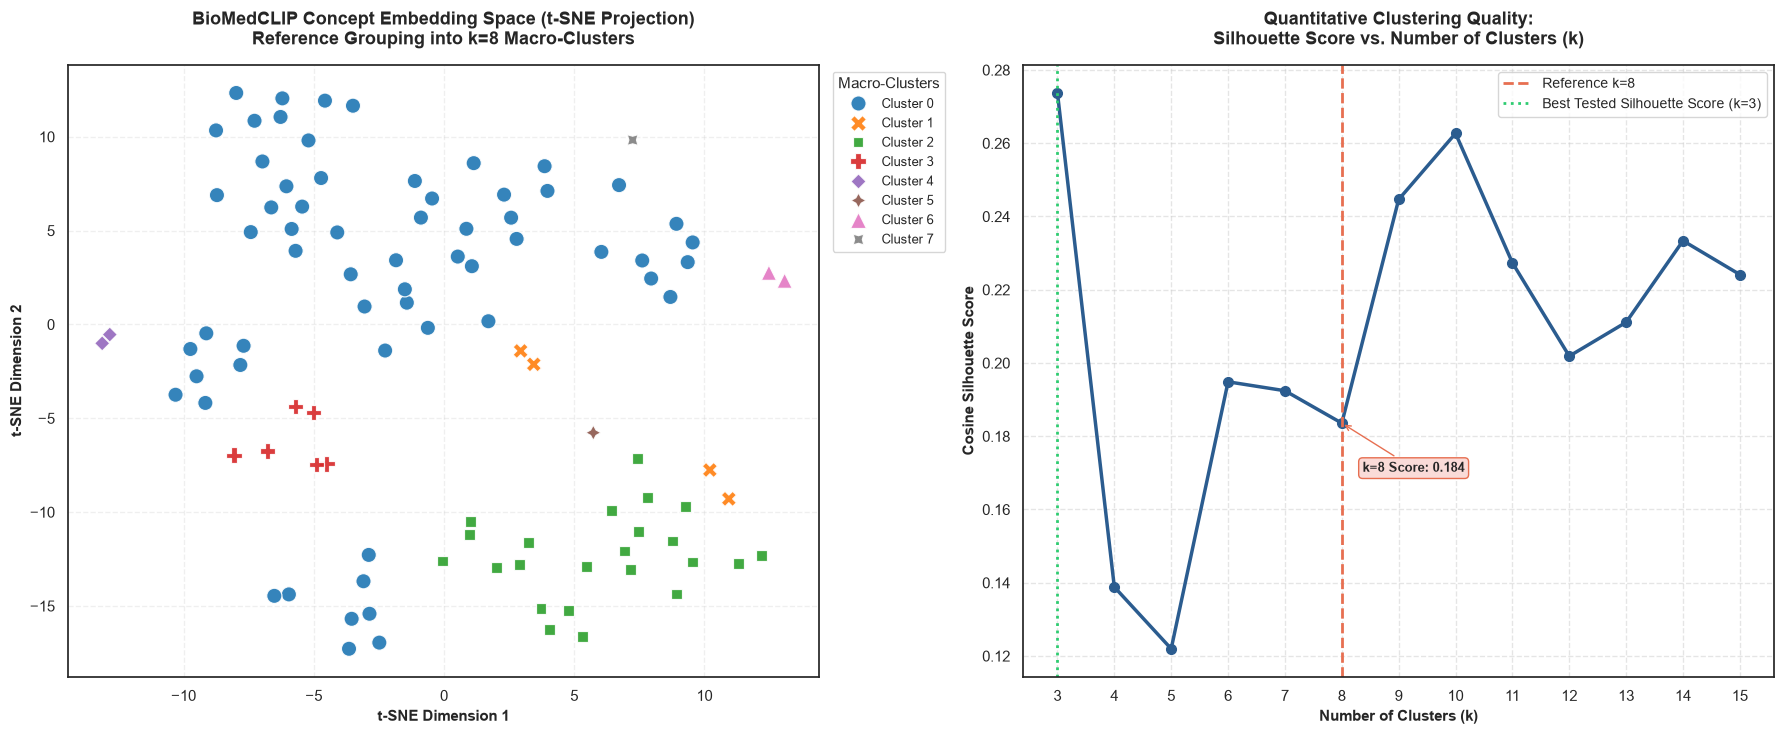

In [8]:
# Project the reference k=8 grouping; score selection uses the original embeddings.
tsne = TSNE(
    n_components=2,
    perplexity=min(15, len(validation_embeddings) - 1),
    random_state=42,
    metric="cosine",
)
embeddings_2d = tsne.fit_transform(validation_embeddings)
validation_plot_df = validation_hierarchy_df.copy()
validation_plot_df["tsne_x"] = embeddings_2d[:, 0]
validation_plot_df["tsne_y"] = embeddings_2d[:, 1]
validation_plot_df["cluster_label"] = validation_plot_df["macro_cluster"].map(
    lambda cluster: f"Cluster {int(cluster)}"
)
cluster_order = [
    f"Cluster {int(cluster)}"
    for cluster in sorted(validation_plot_df["macro_cluster"].unique())
]
palette = dict(zip(cluster_order, sns.color_palette("tab10", len(cluster_order))))

with sns.axes_style("white"), sns.plotting_context("notebook"):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
    sns.scatterplot(
        data=validation_plot_df,
        x="tsne_x", y="tsne_y",
        hue="cluster_label", hue_order=cluster_order,
        style="cluster_label", style_order=cluster_order,
        palette=palette, s=120, alpha=0.9,
        ax=axes[0], legend="full",
    )
    axes[0].set_title(
        "BioMedCLIP Concept Embedding Space (t-SNE Projection)\n"
        "Reference Grouping into k=8 Macro-Clusters",
        fontsize=13, fontweight="bold", pad=15,
    )
    axes[0].set_xlabel("t-SNE Dimension 1", fontsize=11, fontweight="bold")
    axes[0].set_ylabel("t-SNE Dimension 2", fontsize=11, fontweight="bold")
    axes[0].grid(True, linestyle="--", alpha=0.3)

    axes[0].legend(
        loc="upper left", bbox_to_anchor=(1.01, 1),
        title="Macro-Clusters", title_fontsize=11, fontsize=9.5,
    )

    axes[1].plot(
        k_range, silhouette_scores, marker="o", linewidth=2.5,
        color="#2B5C8F", markersize=7,
    )
    axes[1].axvline(
        x=reference_k, color="#E76F51", linestyle="--", linewidth=2,
        label="Reference k=8",
    )
    axes[1].axvline(
        x=optimal_k, color="#2ECC71", linestyle=":", linewidth=2,
        label=f"Best Tested Silhouette Score (k={optimal_k})",
    )
    axes[1].set_title(
        "Quantitative Clustering Quality:\nSilhouette Score vs. Number of Clusters (k)",
        fontsize=13, fontweight="bold", pad=15,
    )
    axes[1].set_xlabel("Number of Clusters (k)", fontsize=11, fontweight="bold")
    axes[1].set_ylabel("Cosine Silhouette Score", fontsize=11, fontweight="bold")
    axes[1].set_xticks(k_range)
    axes[1].grid(True, linestyle="--", alpha=0.5)
    axes[1].legend(loc="best", fontsize=10)
    axes[1].annotate(
        f"k=8 Score: {score_at_8:.3f}",
        xy=(reference_k, score_at_8), xytext=(15, -35),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color="#E76F51"),
        fontsize=9.5, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FADBD8", ec="#E76F51", lw=1),
    )
    plt.tight_layout()
    fig.savefig(os.path.join(save_dir, "cluster_validation_k8.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

validation_plot_df.to_csv(os.path.join(save_dir, "tsne_reference_k8.csv"), index=False)

## 4. Hierarchical Concept Analysis & Macro-Clusters

We apply **Agglomerative Clustering** with cosine distance and average linkage to the BioMedCLIP parent-concept embeddings for every value in **`CLUSTER_COUNTS`**. Edit this list to compare different resolutions, for example **3, 5, 8, and 10 clusters**.

Each `k_<value>` directory stores concept-level evaluation details, verdict counts and percentages, and plots for each available sample benchmark. `cluster_performance_summary.csv` combines the per-cluster results across all configurations processed in the current run.

The MedGemma verdicts from Step 04 remain fixed: changing k changes how they are grouped, without reevaluating the reports. Cluster IDs belong to a specific k and should be interpreted using the corresponding hierarchy in `hierarchies_by_k`.

**Note on Cluster Activation and Sparsity**: Only a subset of the k clusters may receive evaluated concepts in a sample benchmark. Saved count and percentage tables include **all k clusters**, with zero counts and undefined (`NaN`) percentages for inactive clusters. Plots display active clusters only.

In [14]:
# User-defined list of cluster counts to evaluate. Must be integers from 2 to n_parent_concepts - 1.
CLUSTER_COUNTS = [3, 5, 8, 10]

n_parent_concepts = phrase_metadata["parent_concept"].nunique()
if not CLUSTER_COUNTS or any(
    not isinstance(k, int) or isinstance(k, bool) or not 2 <= k < n_parent_concepts
    for k in CLUSTER_COUNTS
):
    raise ValueError("CLUSTER_COUNTS must contain integers from 2 to n_parent_concepts - 1.")
CLUSTER_COUNTS = list(dict.fromkeys(CLUSTER_COUNTS))

hierarchies_by_k = {}
for k in CLUSTER_COUNTS:
    hierarchy_df, parent_embeddings = build_concept_hierarchy(dict_dir, n_clusters=k)
    hierarchies_by_k[k] = hierarchy_df
    k_dir = os.path.join(save_dir, f"k_{k}")
    os.makedirs(k_dir, exist_ok=True)
    print(f"k={k}: hierarchy ready; output directory: {k_dir}")
    display(hierarchy_df.head())
    print("-" * 50)

Created 3 clinical macro-cluster for the 100 concepts.
k=3: hierarchy ready; output directory: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/05_hierarchical_clustering/k_3


,parent_concept,macro_cluster
0,lung,0
1,lung opacity,0
2,cardiomegaly,0
3,calcinosis,0
4,pulmonary atelectasis,0


--------------------------------------------------
Created 5 clinical macro-cluster for the 100 concepts.
k=5: hierarchy ready; output directory: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/05_hierarchical_clustering/k_5


,parent_concept,macro_cluster
0,lung,0
1,lung opacity,0
2,cardiomegaly,0
3,calcinosis,0
4,pulmonary atelectasis,0


--------------------------------------------------
Created 8 clinical macro-cluster for the 100 concepts.
k=8: hierarchy ready; output directory: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/05_hierarchical_clustering/k_8


,parent_concept,macro_cluster
0,lung,0
1,lung opacity,0
2,cardiomegaly,0
3,calcinosis,2
4,pulmonary atelectasis,0


--------------------------------------------------
Created 10 clinical macro-cluster for the 100 concepts.
k=10: hierarchy ready; output directory: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/05_hierarchical_clustering/k_10


,parent_concept,macro_cluster
0,lung,0
1,lung opacity,0
2,cardiomegaly,4
3,calcinosis,2
4,pulmonary atelectasis,0


--------------------------------------------------


### Aggregation over Semantic Macro-Clusters

To analyze the performance at a coarser granularity, we aggregate the existing MedGemma verdicts (*Aligned*, *Unaligned*, *Uncertain*) by **semantic macro-cluster**, without reevaluating the concepts.

Before scanning the dataset, we define two fast-access Python dictionaries to optimize lookup speeds:

* **`parent_to_cluster`**: Maps each canonical parent concept (e.g., `"cardiomegaly"`) directly to its assigned macro-cluster ID derived from Agglomerative Clustering (e.g., `Cluster 2`).
* **`phrase_to_parent`**: Connects each specific fine-grained descriptive phrase or synonym from the Step 02 dictionary back to its broader parent concept.

The script iterates through all evaluated images and their corresponding Sparse Autoencoder (SAE) concepts, executing a two-step semantic resolution:

* **Phrase-to-Parent Resolution**: retrieves the parent concept underlying the specific phrase text.
* **Parent-to-Cluster Mapping**: assigns the corresponding macro-cluster ID to that parent concept.

Successfully matched entries are appended to an `all_details` list as structured dictionary records containing the image index, the concept string, the MedGemma evaluation verdict (*Aligned*, *Unaligned*, or *Uncertain*), and the target macro-cluster ID.

Finally, we aggregate the matched entries:

* **Grouping & Counting**: `.groupby(['macro_cluster', 'verdict']).size()` computes the frequency of each verification outcome across individual macro-clusters.
* **Table Pivoting**: `.unstack(fill_value=0)` reshapes the output into a cross-tabulation format where rows represent semantic macro-clusters and columns correspond to evaluation verdicts.
* **Percentage Normalization**: `.div(..., axis=0) * 100` converts absolute category counts into relative row-wise percentages, generating the normalized data structure required for the stacked bar visualizations and summary tables.

In [ ]:
def analyze_macro_clusters_from_df(
    df_eval, hierarchy_df, phrase_metadata, benchmark_name=""
):
  """Aggrega i risultati sui macro-cluster a partire dal DataFrame di valutazione

  e mostra la tabella percentuale.
  """
  parent_to_cluster = {
      str(row["parent_concept"]).strip().lower(): row["macro_cluster"]
      for _, row in hierarchy_df.iterrows()
  }

  phrase_to_parent = dict(
      zip(
          phrase_metadata["text"].str.strip().str.lower(),
          phrase_metadata["parent_concept"].str.strip().str.lower(),
      )
  )

  all_details = []

  for res in df_eval.to_dict("records"):
    img_idx = res["image_index"]
    for detail in res["details"]:
      concept_text = str(detail["concept"]).strip().lower()
      verdict = detail["verdict"]

      parent = phrase_to_parent.get(concept_text, concept_text)
      cluster = parent_to_cluster.get(parent, -1)

      if cluster != -1:
        all_details.append({
            "image_index": img_idx,
            "concept": concept_text,
            "verdict": verdict,
            "macro_cluster": cluster,
        })

  df_details = pd.DataFrame(all_details, columns=["image_index", "concept", "verdict", "macro_cluster"])

  verdicts = ["Aligned", "Unaligned", "Uncertain"]
  cluster_ids = pd.Index(sorted(hierarchy_df["macro_cluster"].unique()), name="macro_cluster")
  cluster_eval = (
      df_details.groupby(["macro_cluster", "verdict"]).size().unstack(fill_value=0)
      .reindex(index=cluster_ids, columns=verdicts, fill_value=0)
  )
  totals = cluster_eval.sum(axis=1)
  cluster_eval_pct = cluster_eval.div(totals.replace(0, np.nan), axis=0) * 100

  print(
      f"\nPerformance sui {hierarchy_df['macro_cluster'].nunique()}"
      f" Macro-Cluster Clinici ({benchmark_name}) (%):"
  )
  display(cluster_eval_pct.round(2))

  return df_details, cluster_eval, cluster_eval_pct

In [ ]:
sample_benchmarks = [10, 50, 100, 500]

performance_tables = []
processed_runs = []
for n in sample_benchmarks:
    csv_path = os.path.join(eval_dir, f"df_evaluation_{n}_samples.csv")
    if not os.path.exists(csv_path):
        print(f"File per N={n} non trovato in {eval_dir}, salto.")
        continue

    df_eval_current = pd.read_csv(csv_path)
    df_eval_current["details"] = df_eval_current["details"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

    for k, hierarchy_df in hierarchies_by_k.items():
        df_details_n, cluster_counts_n, cluster_pct_n = analyze_macro_clusters_from_df(
            df_eval=df_eval_current,
            hierarchy_df=hierarchy_df,
            phrase_metadata=phrase_metadata,
            benchmark_name=f"k={k}, N={n}",
        )
        k_dir = os.path.join(save_dir, f"k_{k}")
        df_details_n.to_csv(os.path.join(k_dir, f"df_details_{n}_samples.csv"), index=False)
        cluster_counts_n.to_csv(os.path.join(k_dir, f"cluster_counts_{n}_samples.csv"))
        cluster_pct_n.to_csv(os.path.join(k_dir, f"cluster_percentages_{n}_samples.csv"))

        summary = cluster_counts_n.add_suffix("_count").join(cluster_pct_n.add_suffix("_pct"))
        summary["total_concepts"] = cluster_counts_n.sum(axis=1)
        summary["active"] = summary["total_concepts"] > 0
        summary.insert(0, "n_clusters", k)
        summary.insert(1, "sample_benchmark", n)
        summary.insert(2, "evaluated_images", len(df_eval_current))
        performance_tables.append(summary.reset_index())
        processed_runs.append((k, n))

summary_columns = [
    "macro_cluster", "n_clusters", "sample_benchmark", "evaluated_images",
    "Aligned_count", "Unaligned_count", "Uncertain_count",
    "Aligned_pct", "Unaligned_pct", "Uncertain_pct", "total_concepts", "active",
]
performance_summary = (
    pd.concat(performance_tables, ignore_index=True)
    if performance_tables else pd.DataFrame(columns=summary_columns)
)
# Write the current run's summary even if inputs are missing, avoiding a stale summary.
performance_summary.to_csv(os.path.join(save_dir, "cluster_performance_summary.csv"), index=False)
print(f"Saved performance for {len(processed_runs)} (k, sample benchmark) combinations.")


Performance sui 3 Macro-Cluster Clinici (k=3, N=10) (%):


verdict,Aligned,Unaligned,Uncertain
macro_cluster,,,
0,6.45,25.00,68.55
1,60.00,20.00,20.00
2,0.00,33.33,66.67



Performance sui 5 Macro-Cluster Clinici (k=5, N=10) (%):


verdict,Aligned,Unaligned,Uncertain
macro_cluster,,,
0,6.49,25.54,67.97
1,6.25,18.75,75.00
2,0.00,33.33,66.67
3,0.00,0.00,100.00
4,60.00,20.00,20.00



Performance sui 8 Macro-Cluster Clinici (k=8, N=10) (%):


...


Performance sui 8 Macro-Cluster Clinici (k=8, N=500) (%):


verdict,Aligned,Unaligned,Uncertain
macro_cluster,,,
0,8.62,21.85,69.53
1,0.88,23.51,75.61
2,5.15,22.29,72.57
3,4.38,36.25,59.37
4,49.23,3.46,47.31
5,0.15,28.38,71.47
6,4.60,3.45,91.95
7,0.56,28.65,70.79



Performance sui 10 Macro-Cluster Clinici (k=10, N=500) (%):


verdict,Aligned,Unaligned,Uncertain
macro_cluster,,,
0,4.25,20.20,75.55
1,21.08,42.02,36.90
2,5.15,22.29,72.57
3,0.88,23.51,75.61
4,10.00,4.00,86.00
5,0.15,28.38,71.47
6,4.60,3.45,91.95
7,0.56,28.65,70.79
8,4.38,36.25,59.37


Saved performance for 16 (k, sample benchmark) combinations.


DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=3, N=10)
Total Macro-Clusters Analyzed: 3
Total Concepts Mapped:         262


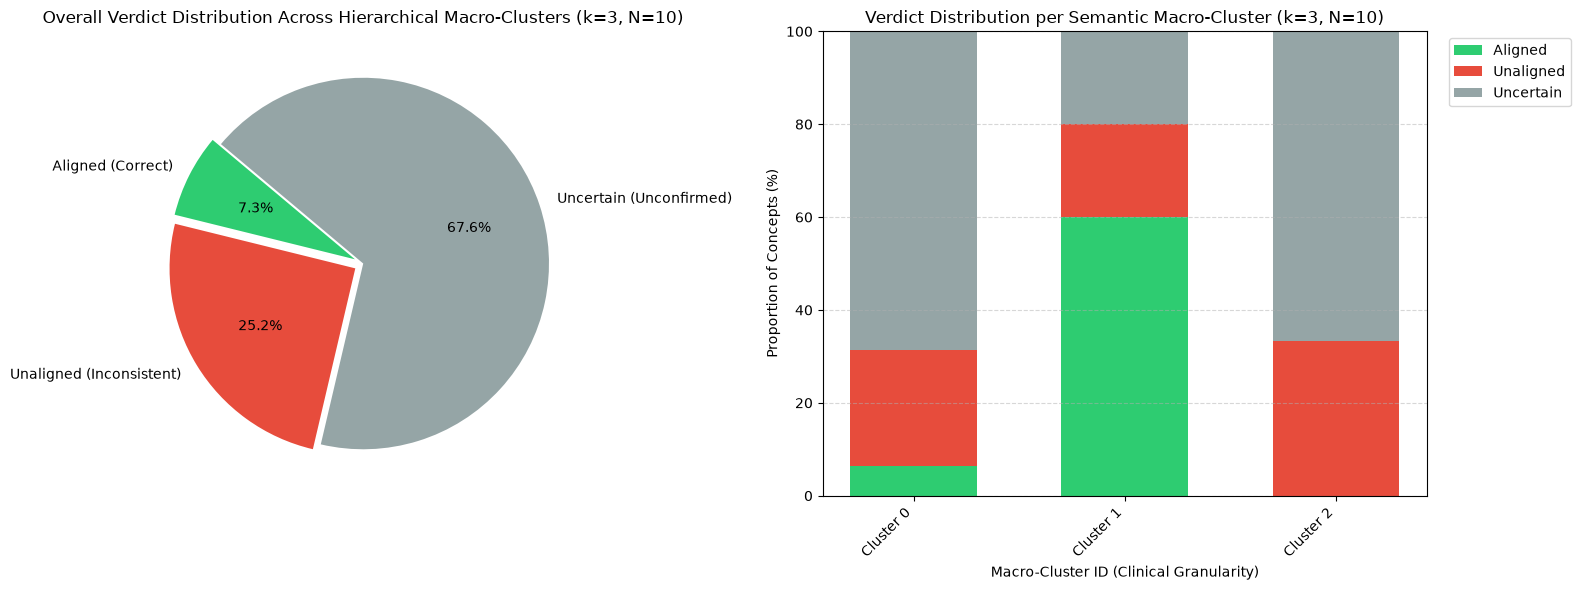

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=5, N=10)
Total Macro-Clusters Analyzed: 5
Total Concepts Mapped:         262


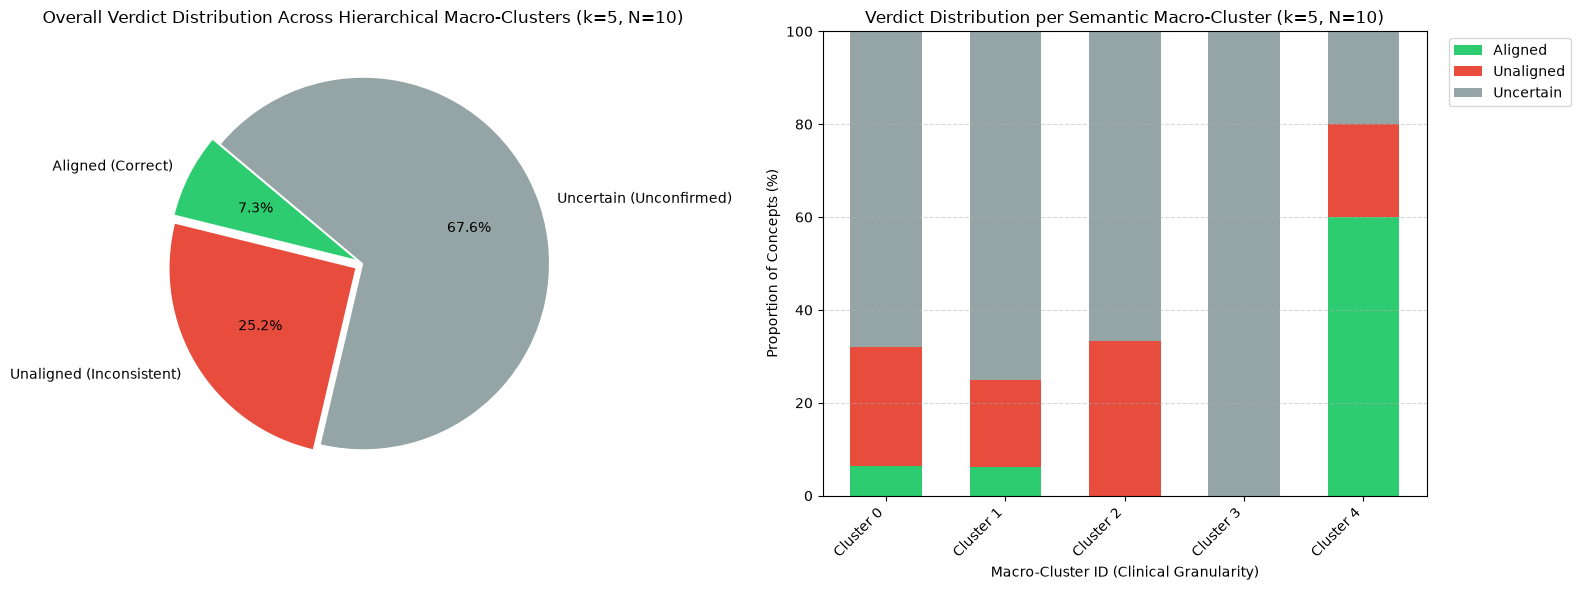

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=8, N=10)
Total Macro-Clusters Analyzed: 8
Total Concepts Mapped:         262


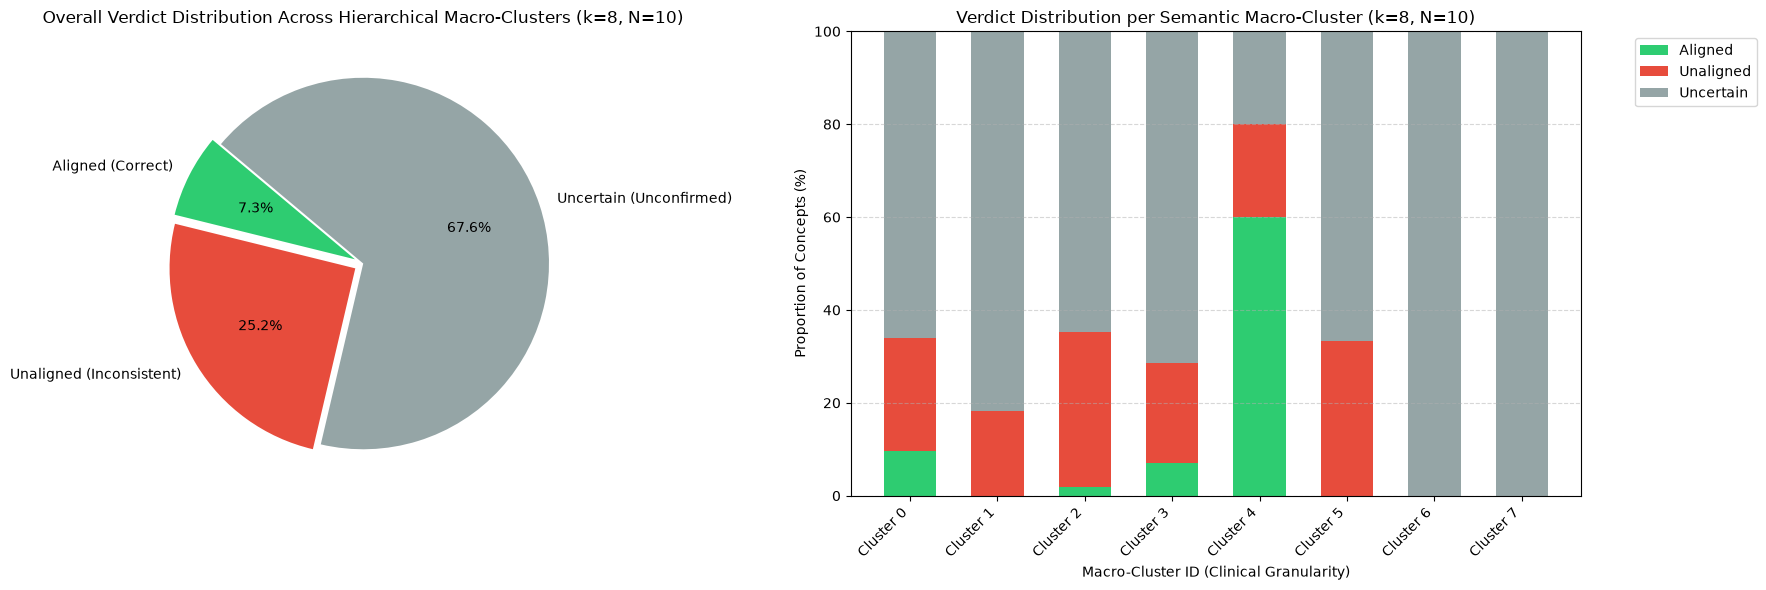

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=10, N=10)
Total Macro-Clusters Analyzed: 10
Total Concepts Mapped:         262


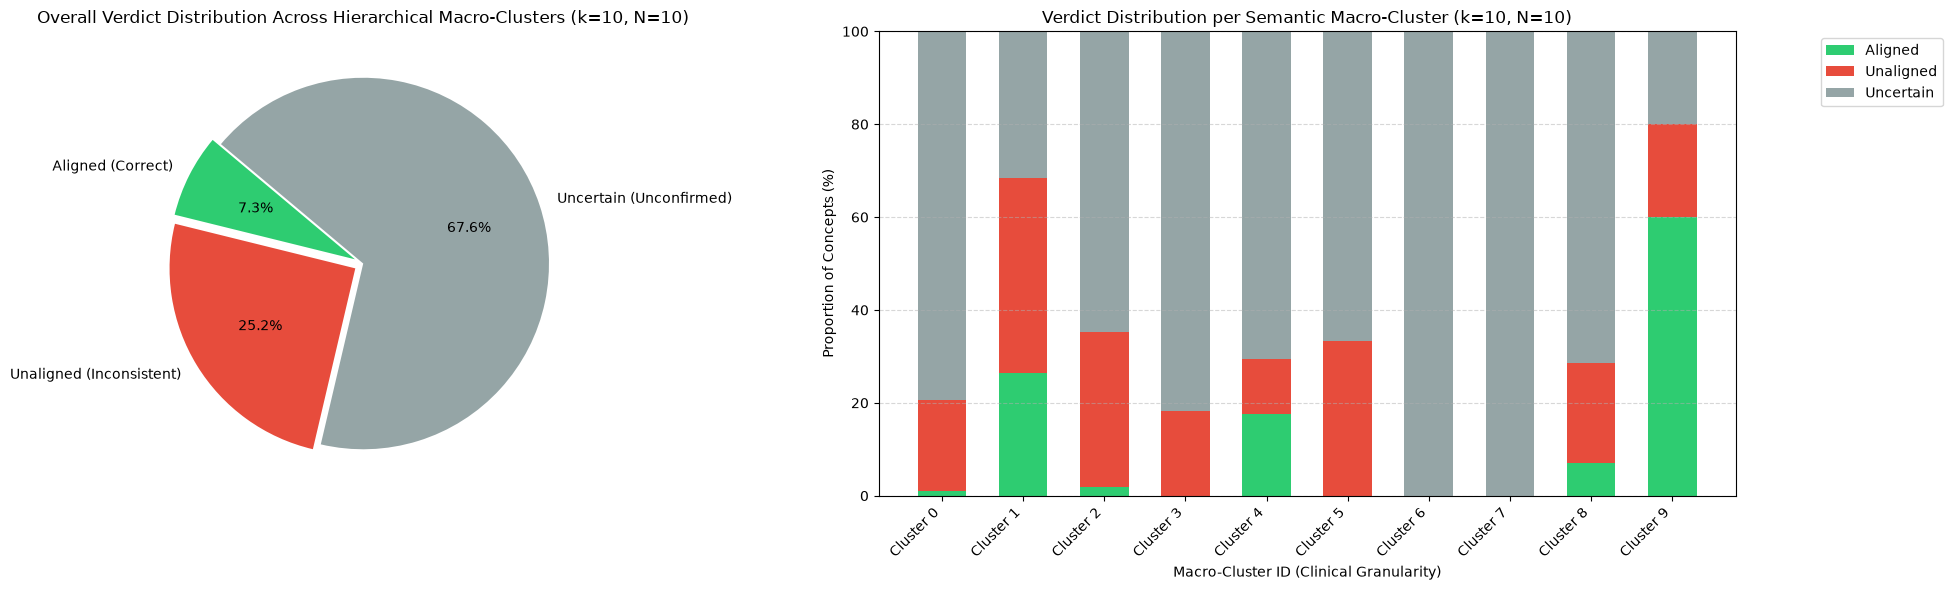

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=3, N=50)
Total Macro-Clusters Analyzed: 3
Total Concepts Mapped:         1311


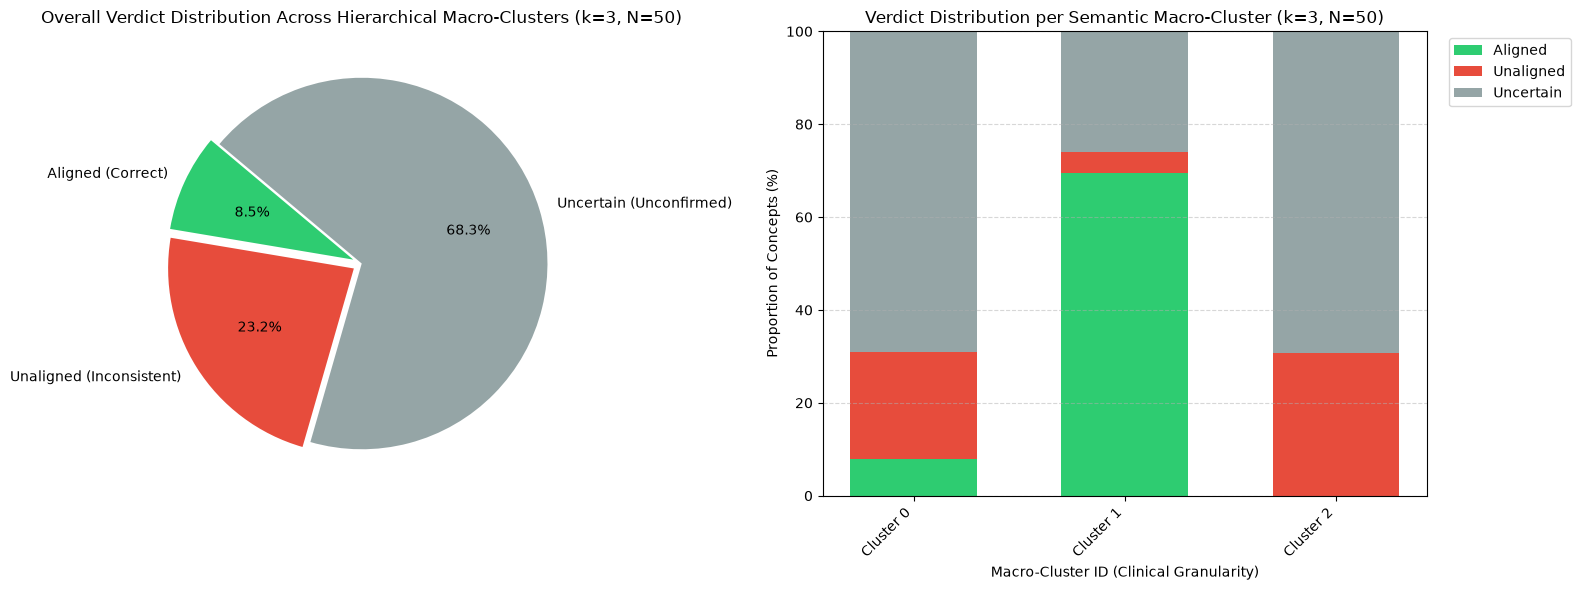

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=5, N=50)
Total Macro-Clusters Analyzed: 5
Total Concepts Mapped:         1311


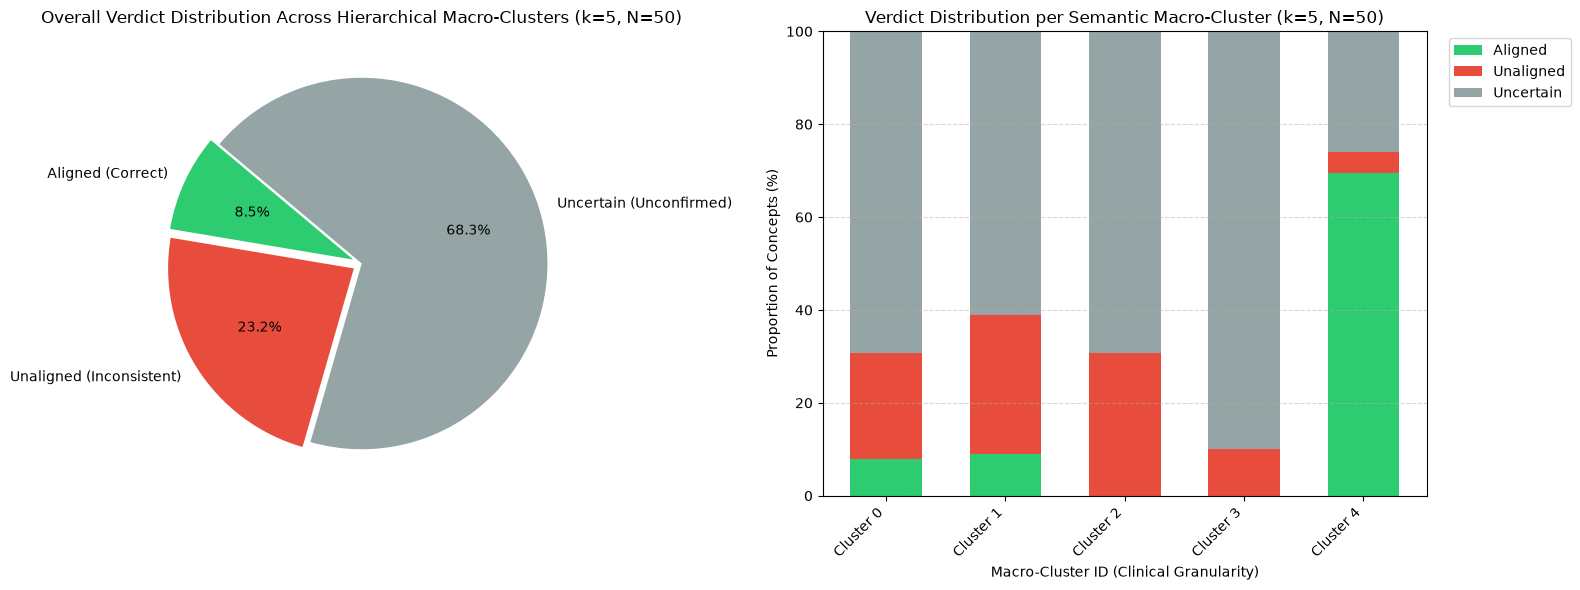

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=8, N=50)
Total Macro-Clusters Analyzed: 8
Total Concepts Mapped:         1311


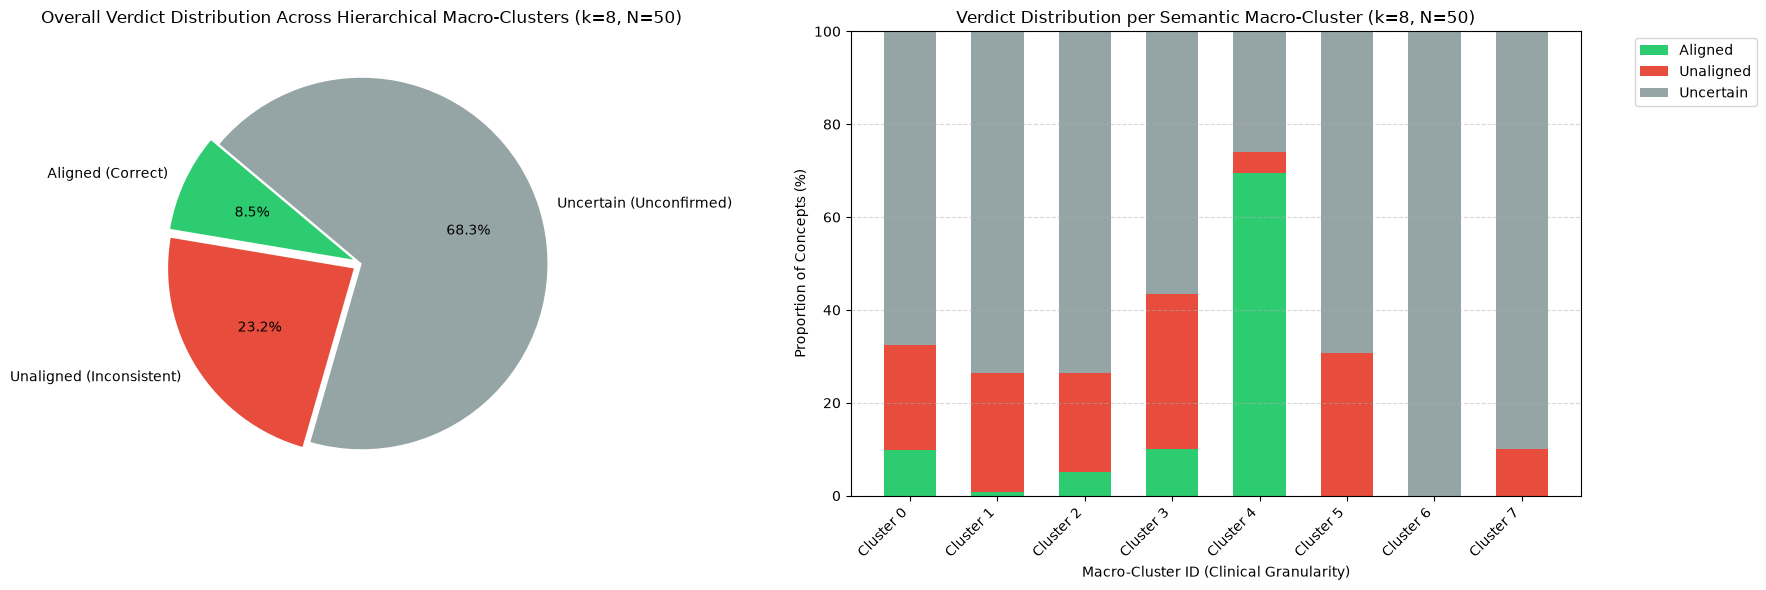

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=10, N=50)
Total Macro-Clusters Analyzed: 10
Total Concepts Mapped:         1311


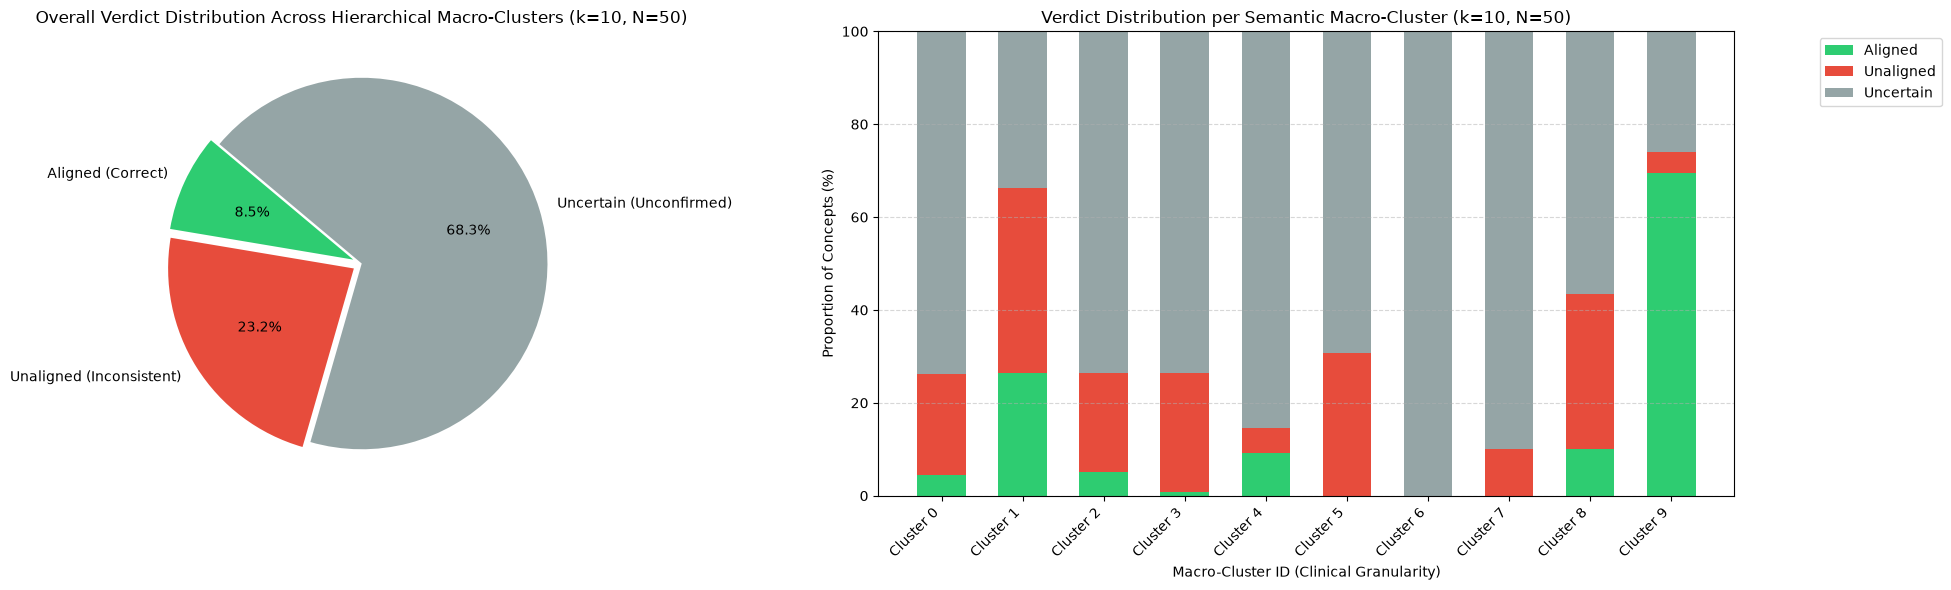

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=3, N=100)
Total Macro-Clusters Analyzed: 3
Total Concepts Mapped:         2623


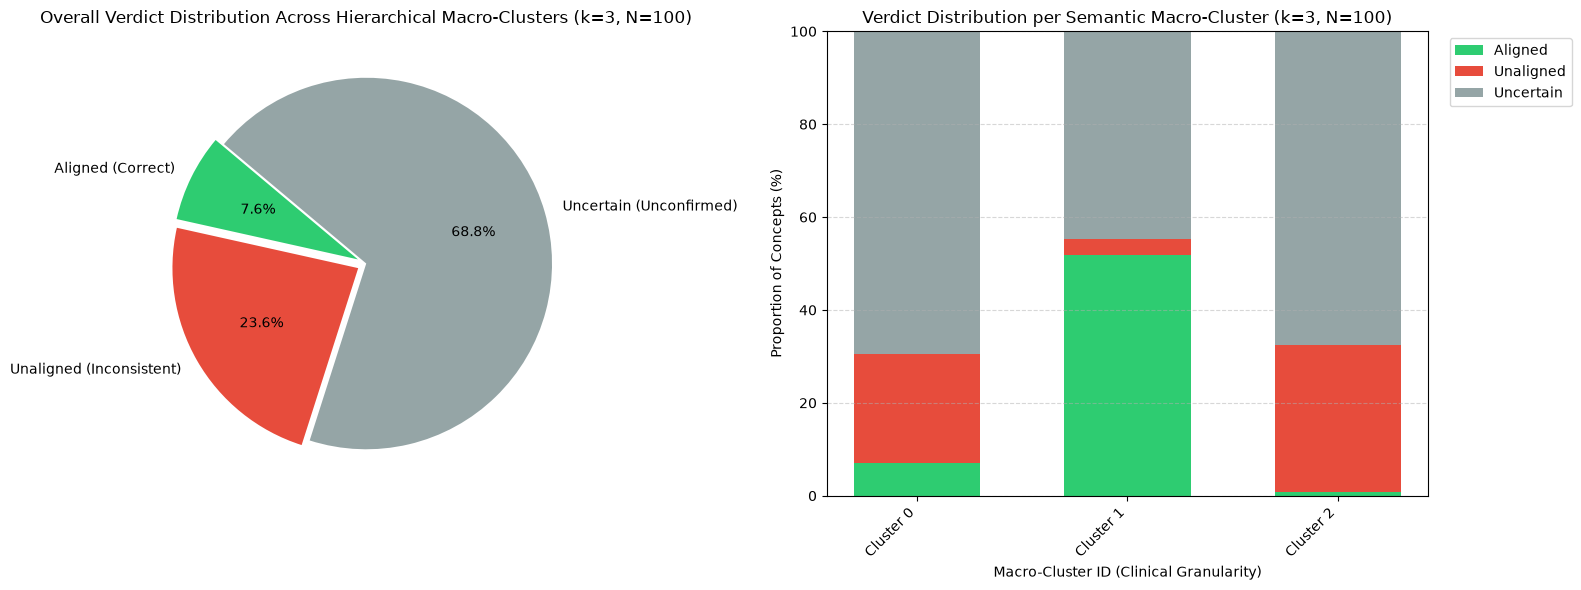

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=5, N=100)
Total Macro-Clusters Analyzed: 5
Total Concepts Mapped:         2623


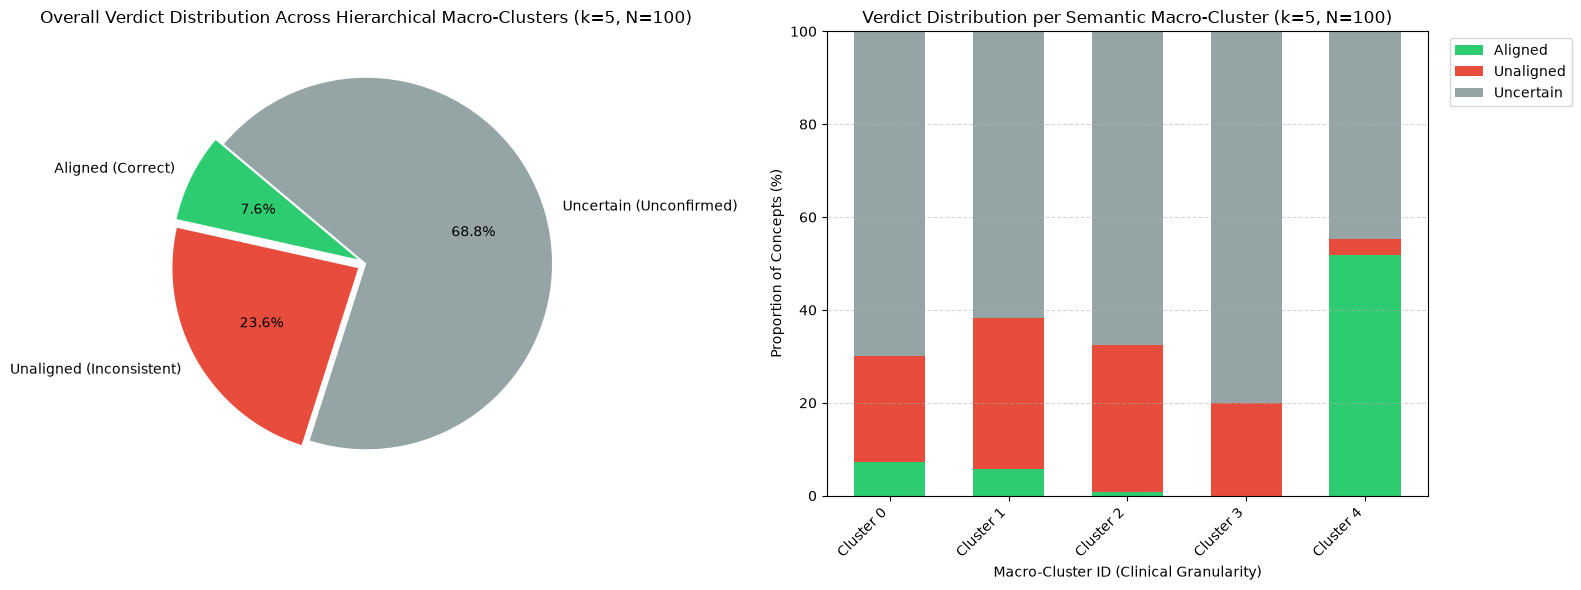

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=8, N=100)
Total Macro-Clusters Analyzed: 8
Total Concepts Mapped:         2623


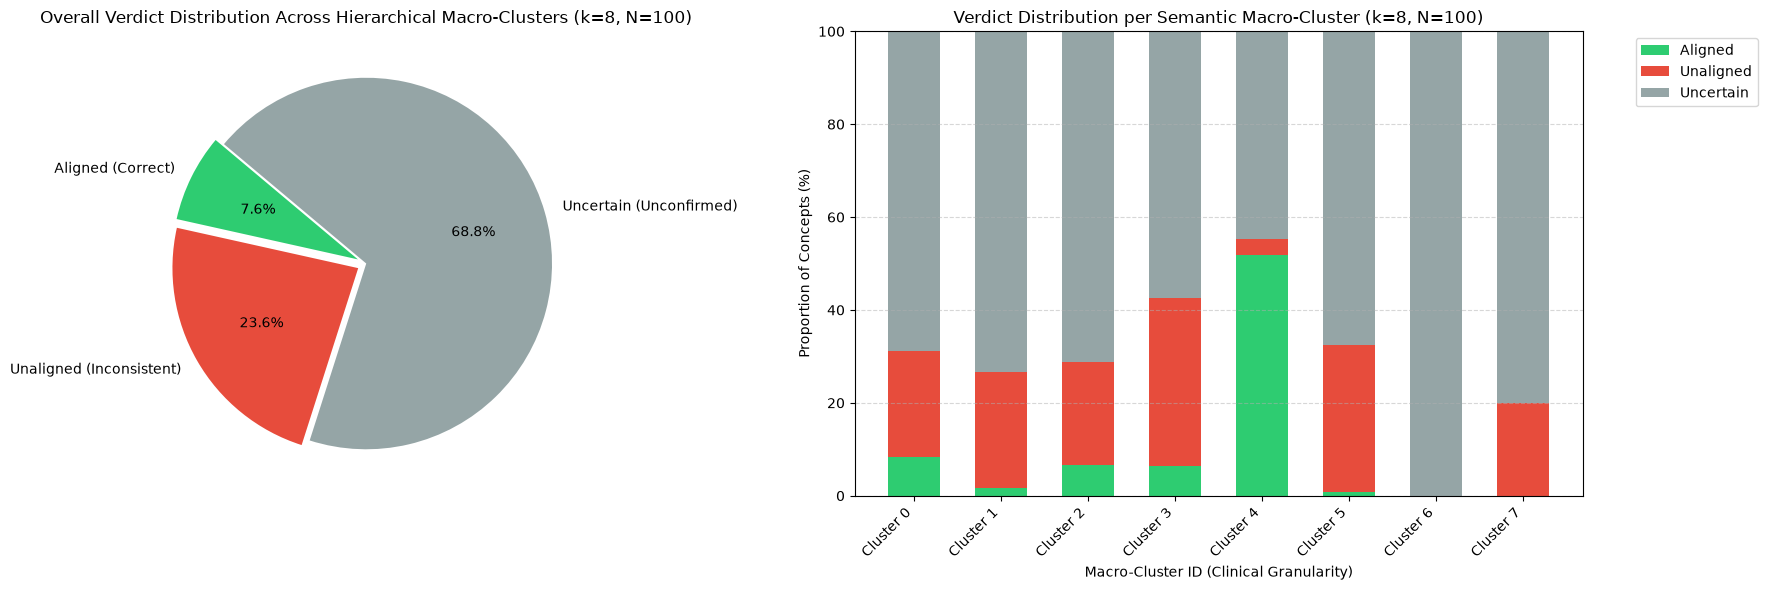

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=10, N=100)
Total Macro-Clusters Analyzed: 10
Total Concepts Mapped:         2623


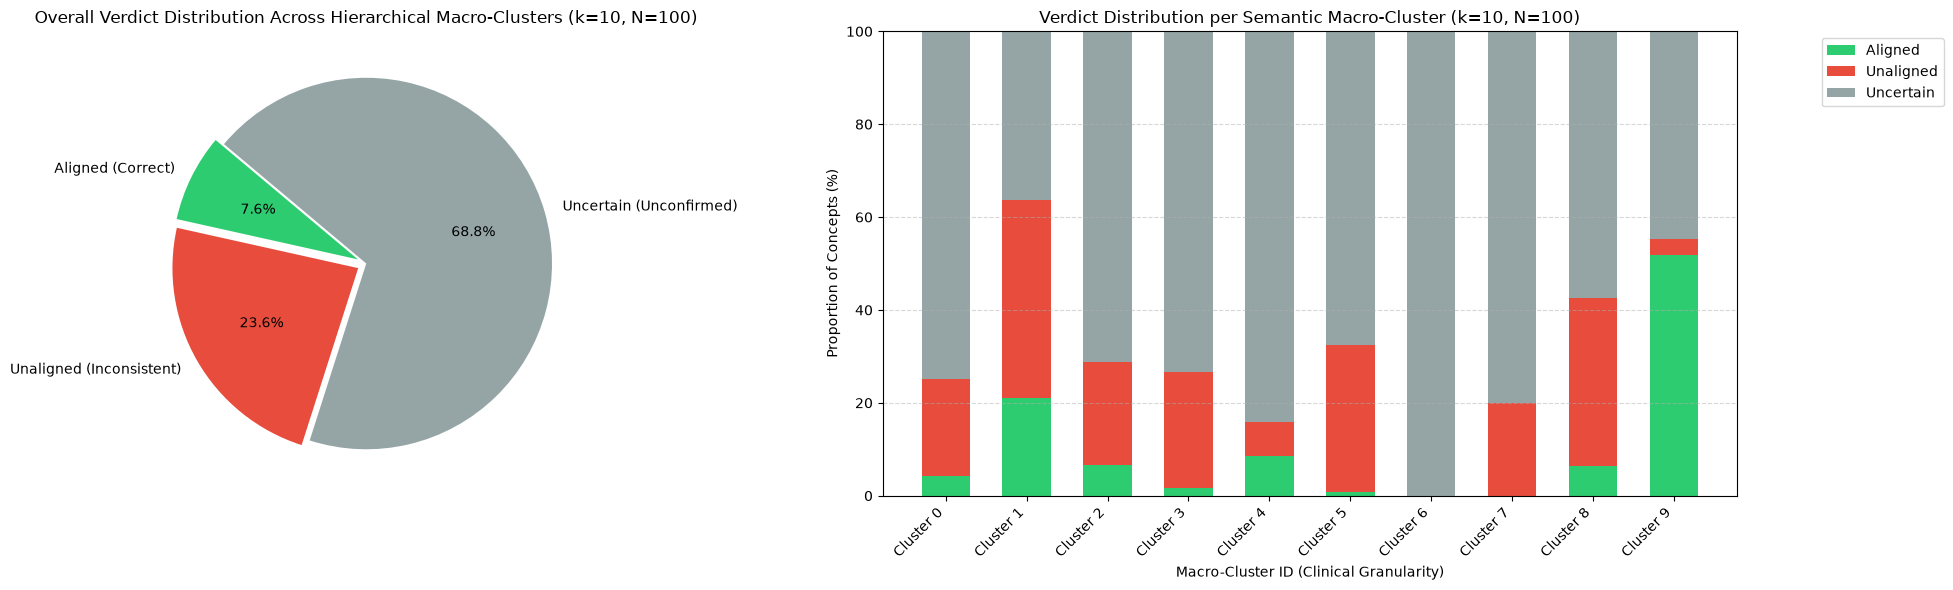

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=3, N=500)
Total Macro-Clusters Analyzed: 3
Total Concepts Mapped:         12996


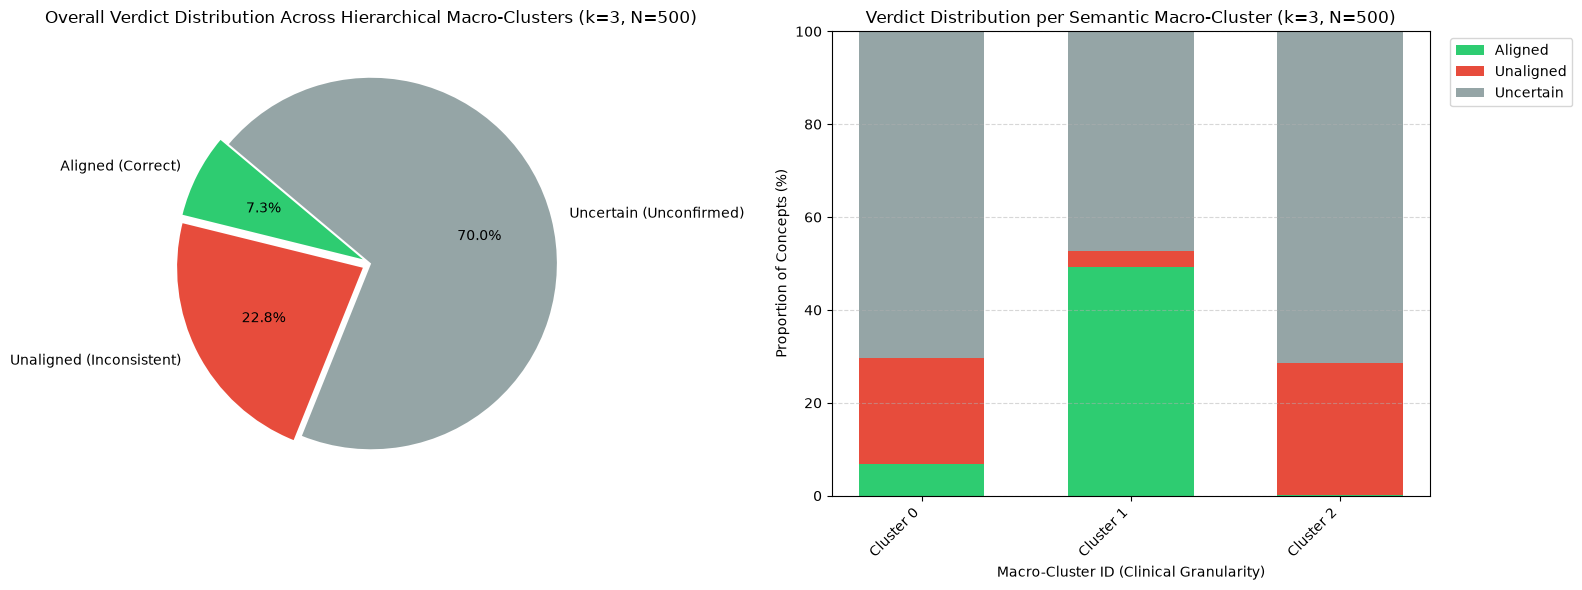

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=5, N=500)
Total Macro-Clusters Analyzed: 5
Total Concepts Mapped:         12996


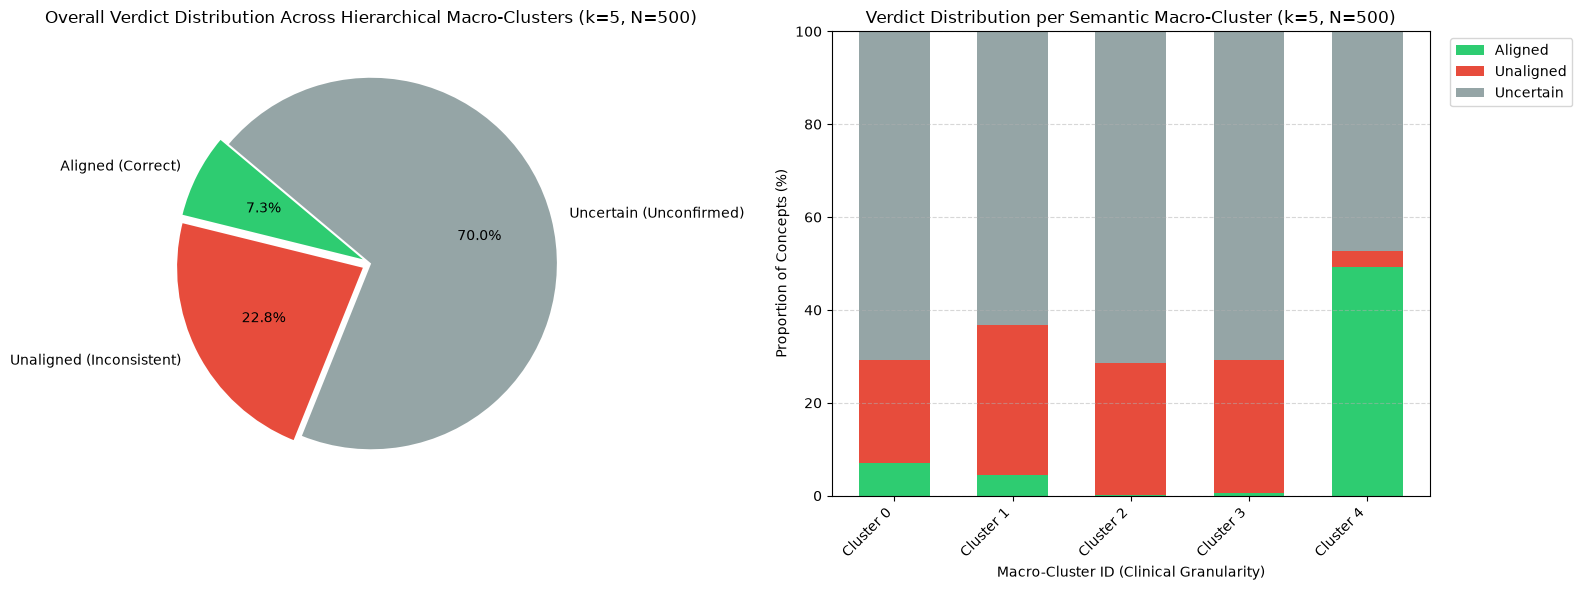

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=8, N=500)
Total Macro-Clusters Analyzed: 8
Total Concepts Mapped:         12996


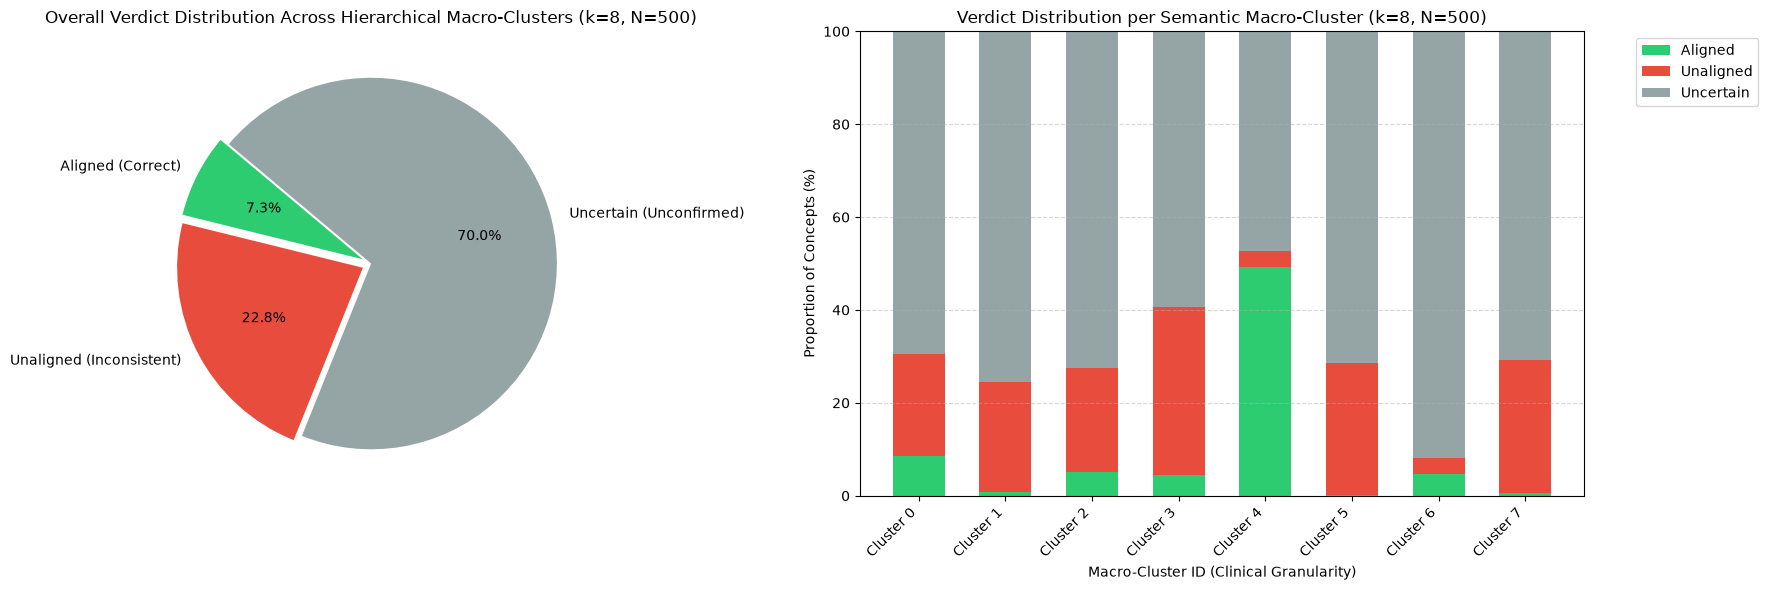

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (k=10, N=500)
Total Macro-Clusters Analyzed: 10
Total Concepts Mapped:         12996


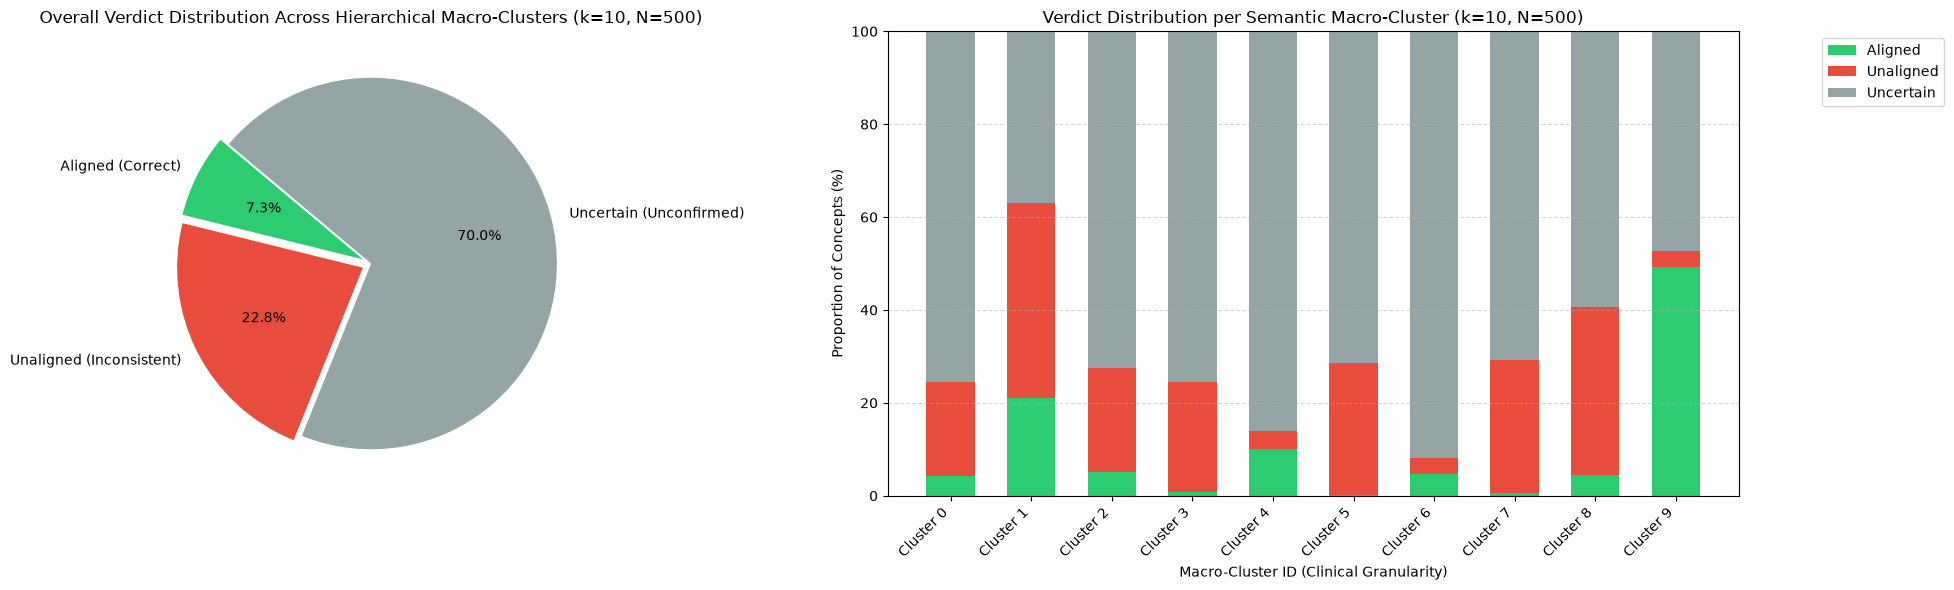

In [ ]:
def plot_and_print_macro_clusters(df_details, benchmark_name="", output_path=None):
  """Stampa l'analisi quantitativa dei macro-cluster e genera i due grafici

  (Torta della distribuzione globale sui cluster + Barre impilate per cluster).
  """
  if df_details.empty:
    print(f"[{benchmark_name}] Nessun dato disponibile per i macro-cluster.")
    return

  cluster_eval_counts = (
      df_details.groupby(["macro_cluster", "verdict"])
      .size()
      .unstack(fill_value=0)
  )

  for v in ["Aligned", "Unaligned", "Uncertain"]:
    if v not in cluster_eval_counts.columns:
      cluster_eval_counts[v] = 0
  cluster_eval_counts = cluster_eval_counts[
      ["Aligned", "Unaligned", "Uncertain"]
  ]

  cluster_eval_pct = (
      cluster_eval_counts.div(cluster_eval_counts.sum(axis=1), axis=0) * 100
  )

  print("=" * 65)
  print(
      "DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION)"
      f" ({benchmark_name})"
  )
  print("=" * 65)
  print(f"Total Macro-Clusters Analyzed: {len(cluster_eval_pct)}")
  print(f"Total Concepts Mapped:         {len(df_details)}")
  print("=" * 65)

  fig, axes = plt.subplots(1, 2, figsize=(max(16, 10 + len(cluster_eval_pct)), 6))

  # Plot 1: Pie Chart global over clusters
  global_cluster_scores = cluster_eval_counts.sum(axis=0) / len(df_details)
  labels = [
      "Aligned (Correct)",
      "Unaligned (Inconsistent)",
      "Uncertain (Unconfirmed)",
  ]
  colors = ["#2ecc71", "#e74c3c", "#95a5a6"]
  explode = (0.05, 0.05, 0)

  axes[0].pie(
      global_cluster_scores,
      labels=labels,
      autopct="%1.1f%%",
      colors=colors,
      startangle=140,
      explode=explode,
  )
  axes[0].set_title(
      "Overall Verdict Distribution Across Hierarchical Macro-Clusters"
      f" ({benchmark_name})"
  )

  # Plot 2: Stacked Bar Chart per macro-cluster
  cluster_indices = [f"Cluster {int(c)}" for c in cluster_eval_pct.index]
  bar_aligned = cluster_eval_pct["Aligned"].values
  bar_unaligned = cluster_eval_pct["Unaligned"].values
  bar_uncertain = cluster_eval_pct["Uncertain"].values

  x_pos = np.arange(len(cluster_indices))

  axes[1].bar(x_pos, bar_aligned, label="Aligned", color="#2ecc71", width=0.6)
  axes[1].bar(
      x_pos,
      bar_unaligned,
      bottom=bar_aligned,
      label="Unaligned",
      color="#e74c3c",
      width=0.6,
  )
  axes[1].bar(
      x_pos,
      bar_uncertain,
      bottom=bar_aligned + bar_unaligned,
      label="Uncertain",
      color="#95a5a6",
      width=0.6,
  )

  axes[1].set_xticks(x_pos)
  axes[1].set_xticklabels(cluster_indices, rotation=45, ha="right")
  axes[1].set_xlabel("Macro-Cluster ID (Clinical Granularity)")
  axes[1].set_ylabel("Proportion of Concepts (%)")
  axes[1].set_title(
      f"Verdict Distribution per Semantic Macro-Cluster ({benchmark_name})"
  )
  axes[1].legend(loc="upper right", bbox_to_anchor=(1.25, 1))
  axes[1].grid(axis="y", linestyle="--", alpha=0.5)
  axes[1].set_ylim(0, 100)

  plt.tight_layout()
  if output_path is not None:
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
  plt.show()
  plt.close(fig)

# Plot only combinations successfully processed in this run.
for k, n in processed_runs:
    k_dir = os.path.join(save_dir, f"k_{k}")
    details_csv_path = os.path.join(k_dir, f"df_details_{n}_samples.csv")
    df_details_current = pd.read_csv(details_csv_path)
    plot_and_print_macro_clusters(
        df_details_current,
        benchmark_name=f"k={k}, N={n}",
        output_path=os.path.join(k_dir, f"macro_cluster_performance_{n}_samples.png"),
    )
